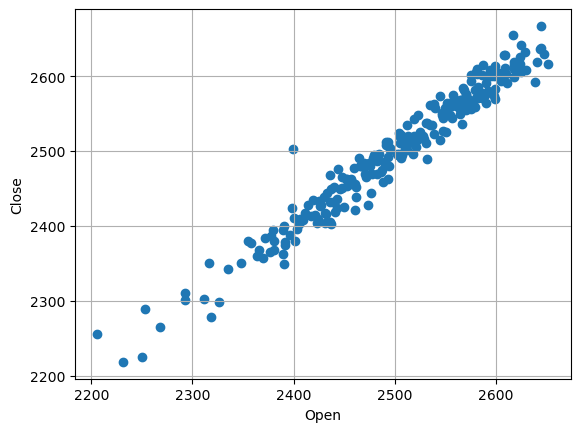

In [1]:
import matplotlib.pyplot as plt

import pandas as pd

data = pd.read_csv('kospi_test.csv')
x = data['Open']
y= data ['Close']
plt.xlabel('Open')
plt.ylabel('Close')
plt.grid(True)
plt.scatter(x, y)
plt.show()

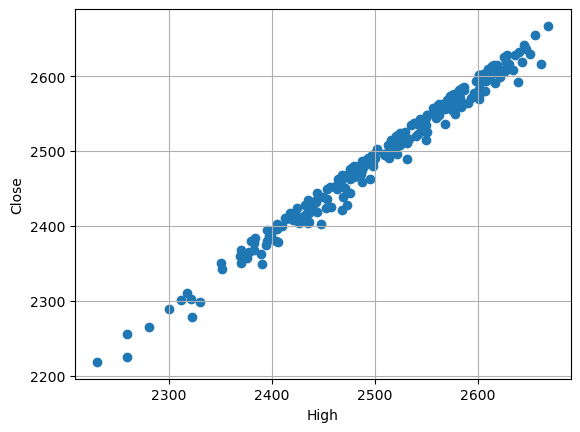

In [2]:
import matplotlib.pyplot as plt

import pandas as pd

data = pd.read_csv('kospi_test.csv')
x = data['High']
y= data ['Close']
plt.xlabel('High')
plt.ylabel('Close')
plt.grid(True)
plt.scatter(x, y)
plt.show()

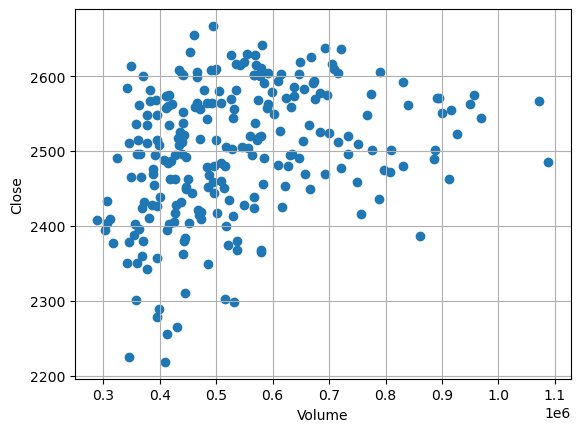

In [3]:
import matplotlib.pyplot as plt

import pandas as pd

data = pd.read_csv('kospi_test.csv')
x = data['Volume']
y= data ['Close']
plt.xlabel('Volume')
plt.ylabel('Close')

plt.scatter(x, y)
plt.grid(True)
plt.show()

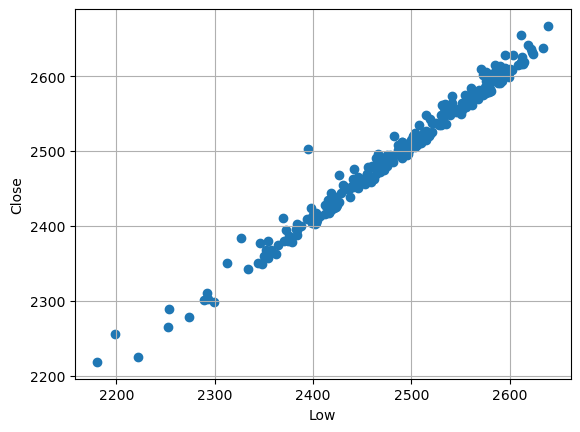

In [4]:
import matplotlib.pyplot as plt

import pandas as pd

data = pd.read_csv('kospi_test.csv')
x = data['Low']
y= data ['Close']
plt.xlabel('Low')
plt.ylabel('Close')
plt.grid(True)
plt.scatter(x, y)
plt.show()

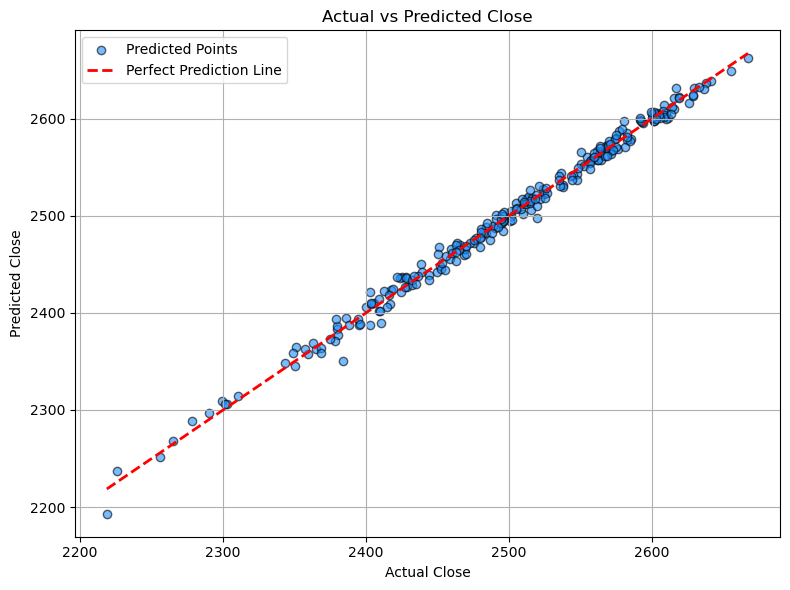

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data = pd.read_csv('kospi_test.csv')

X = data[['Open', 'High', 'Low','Volume']]
y = data['Close']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, c='dodgerblue', edgecolors='k', alpha=0.6, label='Predicted Points')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Close')
plt.ylabel('Predicted Close')
plt.title('Actual vs Predicted Close')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Simple Linear Regression - MSE: 1351.94, R²: 0.9927


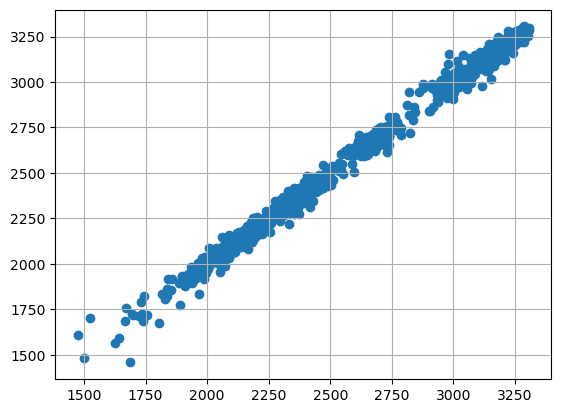

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

data = pd.read_csv('kospi_train.csv')
data['Target'] = data['Close'].shift(-1)
data = data.dropna()

x = data[['Open']]  
y = data['Target']

model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Simple Linear Regression - MSE: {mse:.2f}, R²: {r2:.4f}")

plt.grid(True)
plt.scatter(x, y)
plt.show()

R² Score: 0.9955
Residual Standard Error (RSE): 28.8103
F-Statistic: 43723.79


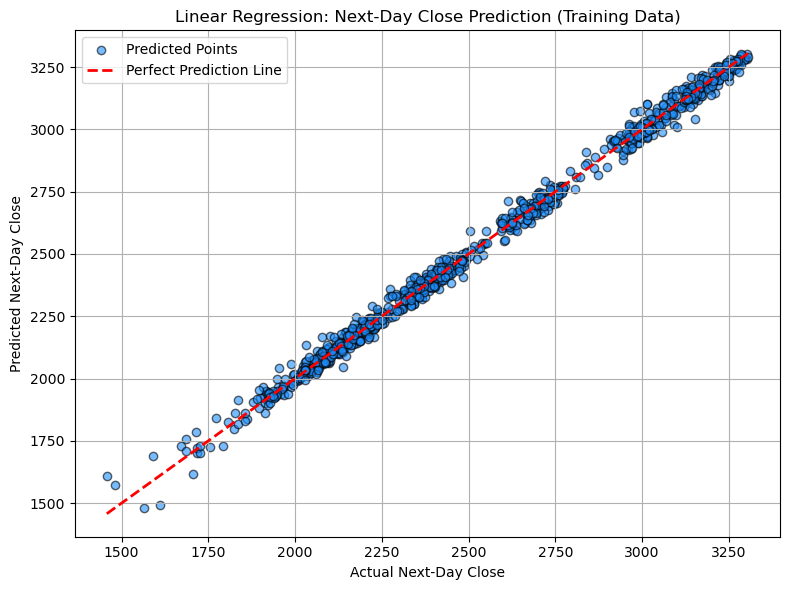

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score


train = pd.read_csv('kospi_train.csv')


train['Target'] = train['Close'].shift(-1)
train = train.dropna()


X = train[['Open', 'High', 'Low', 'Close', 'Volume']]
y = train['Target']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)


r2 = r2_score(y, y_pred)


n = len(y)
p = X.shape[1]
rss = np.sum((y - y_pred) ** 2)
rse = np.sqrt(rss / (n - p - 1))


tss = np.sum((y - np.mean(y)) ** 2)
explained_variance = tss - rss
msr = explained_variance / p
mse = rss / (n - p - 1)
f_statistic = msr / mse


print(f"R² Score: {r2:.4f}")
print(f"Residual Standard Error (RSE): {rse:.4f}")
print(f"F-Statistic: {f_statistic:.2f}")


plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, c='dodgerblue', edgecolors='k', alpha=0.6, label='Predicted Points')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Next-Day Close')
plt.ylabel('Predicted Next-Day Close')
plt.title('Linear Regression: Next-Day Close Prediction (Training Data)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Test Set R² Score: 0.9226
Test Set Residual Standard Error (RSE): 24.5379
Test Set F-Statistic: 564.75


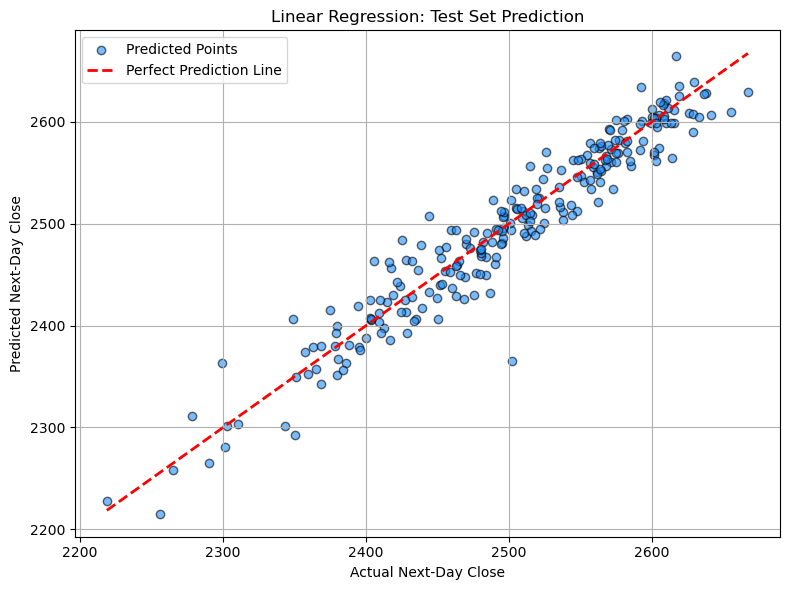

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

train = pd.read_csv('kospi_train.csv')
train['Target'] = train['Close'].shift(-1)
train = train.dropna()

X_train = train[['Open', 'High', 'Low', 'Close', 'Volume']]
y_train = train['Target']


model = LinearRegression()
model.fit(X_train, y_train)

test = pd.read_csv('kospi_test.csv')
test['Target'] = test['Close'].shift(-1)
test = test.dropna()

X_test = test[['Open', 'High', 'Low', 'Close', 'Volume']]
y_test = test['Target']


y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]
rss = np.sum((y_test - y_pred) ** 2)
rse = np.sqrt(rss / (n - p - 1))

tss = np.sum((y_test - np.mean(y_test)) ** 2)
explained_variance = tss - rss
msr = explained_variance / p
mse = rss / (n - p - 1)
f_statistic = msr / mse


print(f"Test Set R² Score: {r2:.4f}")
print(f"Test Set Residual Standard Error (RSE): {rse:.4f}")
print(f"Test Set F-Statistic: {f_statistic:.2f}")


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='dodgerblue', edgecolors='k', alpha=0.6, label='Predicted Points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Next-Day Close')
plt.ylabel('Predicted Next-Day Close')
plt.title('Linear Regression: Test Set Prediction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Test Set R² Score: 0.9932
Test Set Residual Standard Error (RSE): 14.5830
Test Set F-Statistic: 21582.62


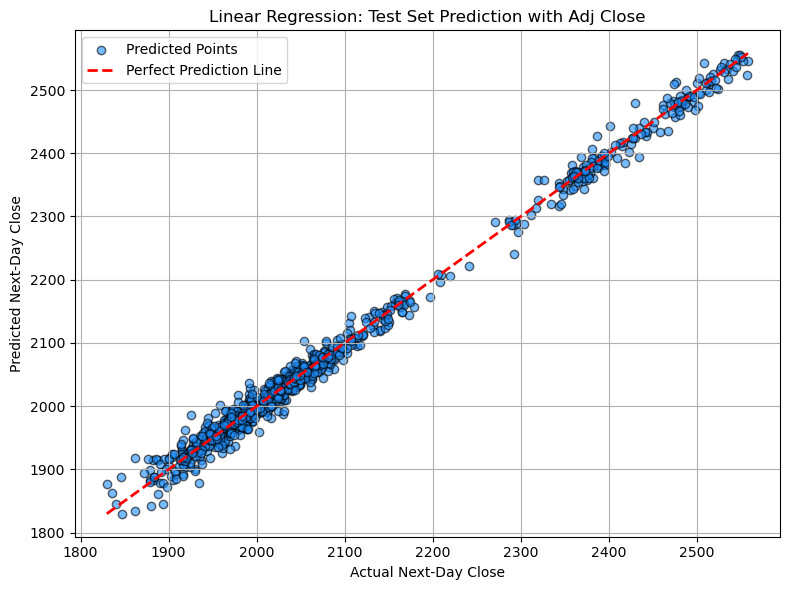

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load the KOSPI data (downloaded from GitHub)
df = pd.read_csv('kospi.csv')

# Drop missing values just in case
df = df.dropna()

# Add target: next day's close
df['Target'] = df['Close'].shift(-1)
df = df.dropna()

# Split into train and test (e.g. 80/20 split)
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

# Define predictors (including 'Adj Close')
predictors = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

X_train = train[predictors]
y_train = train['Target']
X_test = test[predictors]
y_test = test['Target']

# Train model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]
rss = np.sum((y_test - y_pred) ** 2)
rse = np.sqrt(rss / (n - p - 1))

tss = np.sum((y_test - np.mean(y_test)) ** 2)
explained_variance = tss - rss
msr = explained_variance / p
mse = rss / (n - p - 1)
f_statistic = msr / mse

# Output results
print(f"Test Set R² Score: {r2:.4f}")
print(f"Test Set Residual Standard Error (RSE): {rse:.4f}")
print(f"Test Set F-Statistic: {f_statistic:.2f}")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='dodgerblue', edgecolors='k', alpha=0.6, label='Predicted Points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Next-Day Close')
plt.ylabel('Predicted Next-Day Close')
plt.title('Linear Regression: Test Set Prediction with Adj Close')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
